# 03 - Black-box benchmark on the simulated panel

The end-to-end black box of the methodology chapter (S3.2.3): `alpha_bb_{t+1} = g_theta(x_t)`
maps the macro-financial features directly to the allocation with **no PD intermediate**,
trained end-to-end on decision regret (eq. 3.33 / 3.38). The harness is copied from
`02_pto_simulated_panel` - same load/align, decision environment, evaluation, metrics and
plots - and the PTO models plus both persistence baselines are **re-run here on identical
expanding windows**, so every Diebold-Mariano comparison shares the same test dates.

Shared with notebook 02 (the fairness rule): features and timing (`x_t -> t+1`),
per-window `StandardScaler`, expanding windows with `REFIT_EVERY`, alpha grid and utility
constants, realised evaluation at `K_IRB_true_{t+1}`, the two-oracle regret decomposition,
the DM machinery, and architecture capacity / hyperparameter budget (the policy networks
reuse the same linear and two-hidden-layer MLP bodies with a sigmoid head, eq. 3.30-3.31,
whose output is now read as `alpha` instead of PD).

Different by design: no prediction stage, no NLL/MSE, no median-bias correction, no
expected-utility or certainty-equivalent decision stage - the network **is** the decision
rule. Headroom available to regret-trained methods is measured by `mean_regret_vs_bayes`
of the NLL+EU PTO pipeline reported alongside.


In [1]:
from __future__ import annotations

import json
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook needs PyTorch for the linear and MLP PTO models. "
        "Install the project requirements or select the project kernel."
    ) from exc

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data" / "simulated_pd_panel.csv").exists():
    ROOT = ROOT.parent

PANEL_CSV = ROOT / "data" / "simulated_pd_panel.csv"
METADATA_PATH = ROOT / "data" / "simulated_pd_panel_metadata.json"
FIGURES_DIR = ROOT / "figures" / "blackbox_pd_irb_sim"
RESULTS_DIR = ROOT / "models" / "notebooks" / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Project root: {ROOT}")
print(f"Panel: {PANEL_CSV.relative_to(ROOT)}")
print(f"Figures: {FIGURES_DIR.relative_to(ROOT)}")
print(f"Results: {RESULTS_DIR.relative_to(ROOT)}")

Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Panel: data/simulated_pd_panel.csv
Figures: figures/blackbox_pd_irb_sim
Results: models/notebooks/results


## Configuration

Decision and Basel constants are read from the simulator's metadata JSON so the two
notebooks cannot silently diverge; the asserts below fail loudly if the panel was built
with different constants than expected.

The simulated panel is long (~1000 quarters), so refitting every window is unnecessary
and slow. `REFIT_EVERY = 8` refits the scaler and models every 8th test quarter and
reuses them in between (predictions are still one-step-ahead and use only past data).
Set `REFIT_EVERY = 1` to reproduce the strict every-window protocol of the empirical
notebook. `ModelConfig` uses a larger batch and fewer epochs than the empirical notebook
because the training windows are roughly 5x longer.
The `LOSS` / `NLL_*` / `BIAS_CORRECTION` switches govern the **PTO predictor only**,
re-run here unchanged for the aligned comparison. The black box does not predict PD and
does not use the NLL; it trains on realised regret (see the dedicated section below).
`BB_SEEDS` / `BB_MODEL_CFG` pin the black box to the same seed-ensemble effort and
capacity/optimiser/early-stopping budget as the PTO MLP (fairness rule).


In [2]:
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    META = json.load(f)
CONST = META["constants"]

# Decision and Basel constants (from the simulator, asserted rather than assumed)
LGD = float(CONST["LGD"])
M = float(CONST["M"])
K1 = float(CONST["K1"])
LEVERAGE = float(CONST["ell"])
Y_BAR = float(CONST["Y_BAR"])
LAMBDA = float(CONST["lambda_shortfall"])
APPLY_PD_FLOOR = bool(CONST.get("APPLY_PD_FLOOR", True))
PD_FLOOR = float(CONST.get("PD_FLOOR", 3e-4))
assert LGD == 0.45 and K1 == 1.0 and LEVERAGE == 15.0, "Panel constants differ from expected calibration."

PD_Q_CLIP_LOW = 1e-6
PD_Q_CLIP_HIGH = 0.99
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99
ALPHA_GRID = np.linspace(0.0, 1.0, int(CONST.get("alpha_grid_size", 101)))

# Data conventions
HORIZON = 1
DATE_COL = "date"
FEATURE_COLS = list(META["feature_cols"])

# Modelling choices (mirroring the empirical notebook)
TARGET_TRANSFORM = "logit"      # "logit" or "level"
TRAIN_TARGET = "realised"       # "realised" (c_{t+1}/LGD, default) or "true" (ablation)
MLP_SEEDS = (42, 43, 44, 45, 46)
REFIT_EVERY = 8                 # 1 = strict every-window refits

# Decision-stage and bias-correction choices (see the dedicated markdown section below)
DECISION_RULE = "expected"      # "expected" (max E[U] under Vasicek given pd_hat) or "certainty"
BIAS_CORRECTION = True          # median-bias inversion; only active when LOSS == "mse"
RHO_SCALE = float(CONST.get("RHO_SCALE", 1.0))
GH_NODES = 64                   # Gauss-Hermite nodes for expected-utility quadrature

# Training loss. "nll_vasicek" fits PD by maximum likelihood under the Vasicek density of
# realised rates (in the simulation this is the exact data-generating process, so it is
# the correct likelihood). It targets the MEAN PD directly, so the median-bias correction
# is unnecessary and automatically disabled. "mse" reproduces the MSE pipeline (with the
# correction re-enabled via BIAS_CORRECTION).
LOSS = "nll_vasicek"            # "nll_vasicek" or "mse"
NLL_RHO_MODE = "basel"          # "basel" (rho = NLL_RHO_SCALE * BaselR; exact DGP here) or
                                # "auto" (estimate residual probit variance per window -
                                # the right choice for aggregate empirical data)
NLL_RHO_SCALE = RHO_SCALE       # likelihood correlation = Basel R times this (basel mode)
if LOSS == "nll_vasicek" and TRAIN_TARGET == "true":
    print("WARNING: Vasicek NLL assumes noisy realised targets; use LOSS='mse' for the "
          "TRAIN_TARGET='true' ablation.")

EVAL_SPLITS = {
    "main": {"initial_train_frac": 0.7},
}

@dataclass
class ModelConfig:
    hidden_dim: int = 16
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 64
    epochs: int = 200
    patience: int = 30
    val_frac: float = 0.2
    seed: int = 42

MODEL_CFG = ModelConfig()
print(f"Constants from metadata: LGD={LGD}, LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}, "
      f"PD floor={PD_FLOOR} (applied={APPLY_PD_FLOOR})")
print(f"Features: {FEATURE_COLS}")

# ---- Black-box additions ---------------------------------------------------------------
# The black box maps features directly to the allocation alpha and trains on realised
# decision regret. The LOSS / NLL_* / BIAS_CORRECTION switches above govern the PTO
# predictor ONLY and never touch the black box.
BB_SEEDS = MLP_SEEDS            # same seed-ensemble effort as the PTO MLP (fairness rule)
BB_MODEL_CFG = MODEL_CFG        # identical capacity / optimiser / early-stopping budget
print(f"Black box: policy net (linear + MLP, sigmoid head -> alpha), trained on realised "
      f"regret; seeds {BB_SEEDS}; same ModelConfig as PTO.")


Constants from metadata: LGD=0.45, LEVERAGE=15.0, Y_BAR=0.0168, LAMBDA=10.0, PD floor=0.0003 (applied=True)
Features: ['x_growth', 'x_unemployment', 'x_credit_spread', 'x_yield_curve', 'x_house_price_growth', 'c', 'c_lag1']
Black box: policy net (linear + MLP, sigmoid head -> alpha), trained on realised regret; seeds (42, 43, 44, 45, 46); same ModelConfig as PTO.


## Assumptions and caveats

- **Same decision problem as the simulator**: linear shortfall penalty, and committed
  capital excluded from the available buffer (equivalent to a fixed management buffer
  add-on of `1/LEVERAGE` per unit exposure - intentional, it makes the constraint bind
  in the interior of the alpha grid).
- **Realised utility uses the true capital requirement** `K_IRB_true_{t+1}` from the
  panel, matching the simulator's oracle convention. Models still act on their own
  `k_irb(pd_a_hat)`, so capital misestimation affects the decision but the evaluation is
  against the true requirement.
- **Training on realised implied PD** `c_{t+1}/LGD` keeps the synthetic pipeline parallel
  to the empirical one, where true PD is unobservable. It is unbiased for true PD but
  carries Vasicek noise; `TRAIN_TARGET = "true"` quantifies what that noise costs.
- **No reporting lag**: `c_t` is observable at decision time by construction (stated in
  the simulator's metadata).
- **Constant LGD, constant yield, corporate IRB curve**: inherited from the simulator by
  design so that synthetic and empirical results are comparable.- **Black-box training signal is hindsight-outcome information only**: per training
  sample it uses realised `c_{t+1}`, `K_IRB_true_{t+1}` and the panel's foresight-oracle
  utility `utility_oracle_next` - the same information status as PTO training on realised
  `c_{t+1}/LGD`. These enter as training TARGETS only; the input features are exactly
  `feature_cols`, and nothing from `diagnostic_cols` is ever an input.
- **Empirical counterpart**: in the empirical notebook the training-signal capital
  requirement will be `k_irb(pd_a_realised_{t+1})`, matching how the empirical evaluation
  is done; here it is `K_IRB_true_{t+1}`, matching how all models are evaluated in sim.


## Training loss: Vasicek negative log-likelihood (PTO predictor only)

> Reproduced from notebook 02 for the PTO models re-run here. The black box does not predict PD and does not use the NLL.

With `LOSS = "nll_vasicek"` (default) the models are fit by maximum likelihood under the
Vasicek density of realised rates - in the simulation this is the exact data-generating
process, so it is the correct likelihood. In probit space the model is Gaussian,
`ndtri(x) | p ~ N(ndtri(p)/sqrt(1-rho), rho/(1-rho))`, which makes the NLL closed-form
and differentiable. Its key property: the likelihood is maximised at the MEAN parameter
p, so NLL training is consistent for true PD and needs no median-bias correction (the
correction below auto-disables). `LOSS = "mse"` reproduces the MSE pipeline for
comparison. The loss ladder for the write-up: level-space MSE is mean-consistent but
ill-conditioned; logit-space MSE is well-conditioned but median-biased; Vasicek NLL is
both consistent and well-conditioned.

## Why a median-bias correction and an expected-utility decision stage (PTO only)

> PTO-only mechanisms, reproduced from notebook 02 unchanged. The black box has no prediction to correct and makes no distributional assumption - by training across many realised Vasicek draws it optimises empirical expected utility directly, which is exactly the contrast this notebook is built to measure.

Two mechanisms otherwise wreck PTO on this panel, both consequences of the heavy Vasicek
noise in realised charge-offs (skew: given true PD ~0.3%, the median realised rate is
~0.13% but the mean is 0.3% - rare large draws carry the mean). The median-bias issue
only arises under MSE training; the Vasicek NLL above solves it at the source, and the
correction described here is retained for the `LOSS = "mse"` comparison.

**Median bias.** Logit-space MSE on realised outcomes estimates the conditional MEDIAN of
the noisy realisation, not its mean; the decision needs the mean (= true PD, since
E[realised | PD] = PD under Vasicek). Under Vasicek the two are linked in closed form,
`median = Phi(Phi^-1(p) / sqrt(1 - rho))`, so the trained models' predictions are
corrected by inverting it: `p_hat = Phi(sqrt(1 - rho) * Phi^-1(m_hat))`. This uses only
the Vasicek/Basel structure already assumed everywhere, no oracle information. The
persistence baseline is NOT corrected: a single realised draw is already mean-unbiased.
Both raw (`pd_q_hat_raw`) and corrected (`pd_q_hat`) predictions are stored.

**Certainty-equivalence.** Optimising `U(alpha; c_hat, k_hat)` treats the forecast as if
it will realise with certainty, which ignores the loss distribution's right tail -
exactly what the kinked shortfall penalty punishes. The expected-utility rule instead
maximises `E[U(alpha; c, k_hat)]` where `c` follows the Vasicek distribution implied by
the model's OWN `pd_hat` (same quadrature as the simulator's Bayes oracle). Still PTO:
the prediction model is untouched; only the optimise step uses the assumed distribution.
With a perfect prediction this rule reproduces the Bayes oracle exactly, so
`regret_vs_bayes` becomes a pure measure of prediction error. The certainty-equivalent
allocation and its regret are recorded alongside (`alpha_hat_ce`, `regret_ce`) as an
ablation.

## PD conversions, Basel IRB, and allocation objective

Identical formulas to the empirical notebook. The allocation utility here takes the
capital requirement `k` directly (the panel supplies `K_IRB_true`; models compute
`k_irb_from_annual_pd(pd_a_hat)` for their own decision).

In [3]:
def clip_pd_q(pd_q):
    return np.clip(np.asarray(pd_q, dtype=float), PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)


def clip_pd_a(pd_a):
    return np.clip(np.asarray(pd_a, dtype=float), PD_A_CLIP_LOW, PD_A_CLIP_HIGH)


def quarterly_pd_to_annual(pd_q):
    pd_q = clip_pd_q(pd_q)
    return clip_pd_a(1.0 - np.power(1.0 - pd_q, 4.0))


def k_irb_from_annual_pd(pd_a, lgd=LGD, m=M, apply_floor=APPLY_PD_FLOOR):
    # Basel IRB capital requirement per unit exposure. Input must be annual PD.
    pd_a = clip_pd_a(pd_a)
    if apply_floor:
        pd_a = np.maximum(pd_a, PD_FLOOR)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    r = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
    b = np.square(0.11852 - 0.05478 * np.log(pd_a))
    maturity_adj = (1.0 + (m - 2.5) * b) / (1.0 - 1.5 * b)
    z = norm.ppf(pd_a) / np.sqrt(1.0 - r) + np.sqrt(r / (1.0 - r)) * norm.ppf(0.999)
    k_irb = lgd * (norm.cdf(z) - pd_a) * maturity_adj
    return np.maximum(k_irb, 0.0)


def allocation_utility(alpha, c_q, k, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1):
    # U(alpha; c_q, k). Buffer semantics are intentional: committed capital alpha*k1 is
    # excluded from the buffer, equivalent to a 1/leverage management buffer add-on.
    alpha = np.asarray(alpha, dtype=float)
    exposure = leverage * alpha * k1
    terminal_capital = k1 + exposure * (y_bar - float(c_q))
    committed_capital = alpha * k1
    available_buffer = terminal_capital - committed_capital
    required_capital = float(k) * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    return terminal_capital - lambda_penalty * shortfall


def decision_components(alpha, c_q, k):
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = float(k) * exposure
    shortfall = max(required_capital - available_buffer, 0.0)
    utility = terminal_capital - LAMBDA * shortfall
    return dict(exposure=exposure, terminal_capital=terminal_capital, committed_capital=committed_capital,
                available_buffer=available_buffer, required_capital=required_capital, shortfall=shortfall,
                utility=utility, k_irb=float(k))


def optimise_alpha_grid(c_q, k, alpha_grid=ALPHA_GRID):
    utilities = allocation_utility(alpha_grid, c_q=c_q, k=k)
    best_idx = int(np.argmax(utilities))
    return float(alpha_grid[best_idx]), float(utilities[best_idx])


def basel_r_from_annual_pd(pd_a):
    pd_a = clip_pd_a(pd_a)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    return 0.12 * exp_term + 0.24 * (1.0 - exp_term)


def vasicek_rho(pd_a):
    # Same correlation the simulator uses for the loss draw (Basel R times RHO_SCALE).
    return np.clip(RHO_SCALE * basel_r_from_annual_pd(pd_a), 1e-4, 0.999)


_GH_NODES_Z, _GH_WEIGHTS_Z = np.polynomial.hermite_e.hermegauss(GH_NODES)
_GH_WEIGHTS_Z = _GH_WEIGHTS_Z / _GH_WEIGHTS_Z.sum()


def vasicek_c_given_z(pd_q, rho, z):
    return LGD * norm.cdf((norm.ppf(clip_pd_q(pd_q)) - np.sqrt(rho) * z) / np.sqrt(1.0 - rho))


def median_to_mean_pd(pd_q_median, n_iter=3):
    """Invert the Vasicek median bias of logit-space MSE training.

    Logit-space MSE estimates the conditional median m of the realised rate; the decision
    needs the conditional mean p (= true PD). Under Vasicek,
    m = Phi(Phi^-1(p) / sqrt(1 - rho))  =>  p = Phi(sqrt(1 - rho) * Phi^-1(m)).
    rho depends on p through the Basel formula, so iterate (converges in 2-3 steps).
    """
    m = clip_pd_q(pd_q_median)
    p = m
    for _ in range(n_iter):
        rho = vasicek_rho(quarterly_pd_to_annual(p))
        p = clip_pd_q(norm.cdf(np.sqrt(1.0 - rho) * norm.ppf(m)))
    return p


def optimise_alpha_expected(pd_q_hat, alpha_grid=ALPHA_GRID):
    """Expected-utility PTO decision: maximise E[U(alpha; c, k_hat)] where c follows the
    Vasicek distribution implied by the model's OWN pd_q_hat. Uses only the prediction and
    the Basel/Vasicek formulas - no oracle information. With a perfect prediction this
    reproduces the simulator's Bayes oracle exactly."""
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    k_hat = float(k_irb_from_annual_pd(pd_a_hat))
    rho = float(vasicek_rho(pd_a_hat))
    c_nodes = vasicek_c_given_z(pd_q_hat, rho, _GH_NODES_Z)
    utilities = np.stack([allocation_utility(alpha_grid, c_q=c, k=k_hat) for c in c_nodes], axis=1)
    expected_u = utilities @ _GH_WEIGHTS_Z
    best_idx = int(np.argmax(expected_u))
    return float(alpha_grid[best_idx]), float(expected_u[best_idx])

## Load and align the simulated panel

The forecasting row is `x_t -> quarter t+1`. Targets and evaluation columns are the
next-quarter values; `_true` columns are for evaluation and the oracle benchmarks only
and are asserted never to appear among the features.

In [4]:
def load_simulated_panel(panel_csv, feature_cols, horizon=HORIZON):
    df = pd.read_csv(panel_csv)
    df[DATE_COL] = pd.PeriodIndex(df[DATE_COL], freq="Q").to_timestamp()
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Panel is missing feature columns: {missing}")

    # Next-quarter outcomes for target construction and decision evaluation.
    df["target_date"] = df[DATE_COL].shift(-horizon)
    df["c_q_realised"] = df["c"].shift(-horizon)
    df["pd_q_realised"] = clip_pd_q(df["c_q_realised"] / LGD)
    df["pd_q_true_next"] = df["PD_quarterly_true"].shift(-horizon)
    df["pd_a_true_next"] = df["PD_annual_true"].shift(-horizon)
    df["k_irb_true_next"] = df["K_IRB_true"].shift(-horizon)
    df["alpha_oracle_next"] = df["alpha_oracle"].shift(-horizon)
    df["utility_oracle_next"] = df["utility_oracle"].shift(-horizon)
    df["alpha_bayes_next"] = df["alpha_bayes"].shift(-horizon)
    df["utility_bayes_realised_next"] = df["utility_bayes_realised"].shift(-horizon)

    if TRAIN_TARGET == "realised":
        df["target_pd_q_next"] = df["pd_q_realised"]
    elif TRAIN_TARGET == "true":
        df["target_pd_q_next"] = clip_pd_q(df["pd_q_true_next"])
    else:
        raise ValueError("TRAIN_TARGET must be 'realised' or 'true'.")

    required = list(feature_cols) + ["target_date", "c_q_realised", "pd_q_realised", "pd_q_true_next",
                                     "pd_a_true_next", "k_irb_true_next", "alpha_oracle_next",
                                     "utility_oracle_next", "alpha_bayes_next",
                                     "utility_bayes_realised_next", "target_pd_q_next"]
    df = df.dropna(subset=required).reset_index(drop=True)
    if len(df) < 100:
        raise ValueError(f"Only {len(df)} usable observations; check the panel.")
    return df

df = load_simulated_panel(PANEL_CSV, FEATURE_COLS)

forbidden = {"PD_quarterly_true", "PD_annual_true", "PD_true", "expected_c_quarterly", "K_IRB_true",
             "alpha_oracle", "alpha_bayes", "latent_state", "latent_cycle"}
assert not (forbidden & set(FEATURE_COLS)), "True/diagnostic columns leaked into features."
assert "c" in FEATURE_COLS and "c_lag1" in FEATURE_COLS
print(f"Observations after alignment: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Training target: {TRAIN_TARGET!r} ({'c_(t+1)/LGD' if TRAIN_TARGET == 'realised' else 'true PD (ablation)'})")
display(df[[DATE_COL] + FEATURE_COLS + ["target_pd_q_next", "pd_q_true_next"]].head())

Observations after alignment: 998
Feature date range: 1980-04-01 to 2229-07-01
Training target: 'realised' (c_(t+1)/LGD)


,date,x_growth,x_unemployment,x_credit_spread,x_yield_curve,x_house_price_growth,c,c_lag1,target_pd_q_next,pd_q_true_next
0,1980-04-01,-0.203143,0.897137,-0.055082,-0.208364,0.273917,0.000763,0.000082,0.001724,0.005418
1,1980-07-01,-0.833491,0.699530,0.607612,-0.173439,-0.690280,0.000776,0.000763,0.000188,0.003200
2,1980-10-01,-0.608899,-0.001785,0.141476,0.415671,-0.206404,0.000085,0.000776,0.000350,0.003324
3,1981-01-01,-1.143365,-0.339549,0.567634,-0.941497,0.366174,0.000158,0.000085,0.000522,0.003290
4,1981-04-01,0.126592,-0.095532,-0.437445,0.586255,0.399816,0.000235,0.000158,0.003254,0.004226


## PTO models and training loop (verbatim from 02)

Identical architecture to the empirical notebook: raw-score output whose sigmoid is the
predicted quarterly PD, bias initialised from the pre-validation slice, chronological
train/validation split with shuffled mini-batches, early stopping, MLP seed ensemble.
The loss is selected by `LOSS`: Vasicek NLL on probit targets (default) or MSE on
logit/level targets. Early stopping monitors validation loss in the training space;
`val_rmse_pd_q` is always reported on the PD level for comparability across losses.

In [5]:
def logit_np(p):
    p = np.clip(np.asarray(p, dtype=float), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW)
    return np.log(p / (1.0 - p))


def probit_np(p):
    p = np.clip(np.asarray(p, dtype=float), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW)
    return norm.ppf(p)


def torch_vasicek_nll(score, y_probit, rho_fixed=None):
    """Negative log-likelihood of realised rates under the Vasicek density, parameterised
    by the model's predicted PD (sigmoid of the raw score).

    In probit space the Vasicek model is Gaussian:
        ndtri(x) | p ~ N( ndtri(p) / sqrt(1 - rho), rho / (1 - rho) ),
    with rho either fixed per window (NLL_RHO_MODE = "auto") or
    NLL_RHO_SCALE * BaselR(annualised p) ("basel" - the exact DGP in this simulation).
    Terms not involving the prediction are dropped, except the log-variance, which can
    depend on p through rho. Maximising this likelihood is consistent for the MEAN
    parameter p, so no median-bias correction is needed downstream.
    """
    pd_q = torch.sigmoid(score).clamp(PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)
    if rho_fixed is not None:
        rho = torch.as_tensor(float(rho_fixed))
    else:
        pd_a = (1.0 - torch.pow(1.0 - pd_q, 4.0)).clamp(PD_A_CLIP_LOW, PD_A_CLIP_HIGH)
        exp_term = (1.0 - torch.exp(-50.0 * pd_a)) / (1.0 - float(np.exp(-50.0)))
        rho = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
        rho = torch.clamp(NLL_RHO_SCALE * rho, 1e-4, 0.999)
    mu = torch.special.ndtri(pd_q) / torch.sqrt(1.0 - rho)
    var = rho / (1.0 - rho)
    return torch.mean(0.5 * torch.log(var) + (y_probit - mu) ** 2 / (2.0 * var))


class PDForecaster(nn.Module):
    # Outputs a raw score; predicted quarterly PD is sigmoid(score).
    def __init__(self, input_dim, model_type, hidden_dim=16):
        super().__init__()
        if model_type == "linear":
            self.net = nn.Linear(input_dim, 1)
        elif model_type == "mlp":
            self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                                     nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        else:
            raise ValueError("model_type must be 'linear' or 'mlp'.")

    def forward(self, x):
        return self.net(x).squeeze(-1)


def init_output_bias_for_target(model, y_pre_val):
    y_mean = float(np.clip(np.mean(y_pre_val), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW))
    logit_mean = float(np.log(y_mean / (1.0 - y_mean)))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def train_pd_model(x_train, y_train_pd_q, model_type, model_cfg, seed=None, return_history=False):
    seed = model_cfg.seed if seed is None else int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    y_tr, y_val = y_train_pd_q[:train_size], y_train_pd_q[train_size:]
    if LOSS == "nll_vasicek":
        t_tr, t_val = probit_np(y_tr), probit_np(y_val)
    elif LOSS == "mse" and TARGET_TRANSFORM == "logit":
        t_tr, t_val = logit_np(y_tr), logit_np(y_val)
    elif LOSS == "mse" and TARGET_TRANSFORM == "level":
        t_tr, t_val = y_tr, y_val
    else:
        raise ValueError("LOSS must be 'nll_vasicek' or 'mse'; TARGET_TRANSFORM must be 'logit' or 'level'.")

    train_ds = TensorDataset(torch.tensor(x_tr, dtype=torch.float32), torch.tensor(t_tr, dtype=torch.float32))
    loader_gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=True, generator=loader_gen)

    model = PDForecaster(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_target(model, y_tr)
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)
    mse_fn = nn.MSELoss()

    rho_fixed = None
    if LOSS == "nll_vasicek" and NLL_RHO_MODE == "auto":
        # Residual probit-space variance of the pre-validation slice via OLS with
        # intercept; rho_eff = s2 / (1 + s2) is the Vasicek correlation implied by the
        # noise the data actually shows given the features.
        X_ols = np.hstack([x_tr, np.ones((len(x_tr), 1))])
        beta_ols, *_ = np.linalg.lstsq(X_ols, t_tr, rcond=None)
        resid = t_tr - X_ols @ beta_ols
        dof = max(len(t_tr) - X_ols.shape[1], 1)
        s2 = float(resid @ resid) / dof
        rho_fixed = float(np.clip(s2 / (1.0 + s2), 1e-4, 0.5))

    def compute_loss(score, target):
        if LOSS == "nll_vasicek":
            return torch_vasicek_nll(score, target, rho_fixed=rho_fixed)
        pred = score if TARGET_TRANSFORM == "logit" else torch.sigmoid(score)
        return mse_fn(pred, target)

    x_val_t = torch.tensor(x_val, dtype=torch.float32)
    t_val_t = torch.tensor(t_val, dtype=torch.float32)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train()
        batch_losses = []
        for xb, tb in train_loader:
            optimiser.zero_grad()
            loss = compute_loss(model(xb), tb)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            score_val = model(x_val_t)
            val_loss = compute_loss(score_val, t_val_t).item()
            pd_q_val_np = clip_pd_q(torch.sigmoid(score_val).cpu().numpy())
        history.append({"epoch": epoch + 1, "model": model_type, "seed": seed,
                        "rho_eff": float("nan") if rho_fixed is None else rho_fixed,
                        "train_loss": float(np.mean(batch_losses)), "val_loss": float(val_loss),
                        "val_rmse_pd_q": float(np.sqrt(mean_squared_error(y_val, pd_q_val_np))),
                        "val_mae_pd_q": float(mean_absolute_error(y_val, pd_q_val_np)),
                        "val_mean_pd_q_hat": float(np.mean(pd_q_val_np))})

        if val_loss < best_val - 1e-12:
            best_val, stale_epochs = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def predict_pd_q(model, x):
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(torch.tensor(x, dtype=torch.float32))).cpu().numpy()
    return clip_pd_q(np.atleast_1d(pred))


def train_mlp_ensemble(x_train, y_train_pd_q, model_cfg, seeds=MLP_SEEDS, return_history=False):
    models, first_hist = [], None
    for i, s in enumerate(seeds):
        want_hist = return_history and i == 0
        out = train_pd_model(x_train, y_train_pd_q, "mlp", model_cfg, seed=s, return_history=want_hist)
        if want_hist:
            model, first_hist = out
        else:
            model = out
        models.append(model)
    return models, first_hist


def predict_pd_q_ensemble(models, x):
    preds = np.stack([predict_pd_q(m, x) for m in models], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)

## Black-box policy: features -> alpha, trained on realised regret

Objective (thesis eq. 3.33 / 3.38): mean realised regret over the training window,

    L_BB = (1/T) * sum_t [ U_oracle(t+1) - U(alpha_theta(x_t); c_{t+1}, K_IRB_true_{t+1}) ]

`U_oracle` does not depend on theta, so minimising mean regret is equivalent to maximising
mean realised utility; regret is kept in the loss so training/validation curves read
directly as regret. Implementation notes:

- **Architecture**: `PolicyNet = PDForecaster` - the identical linear / two-hidden-layer
  MLP bodies with a sigmoid head (eq. 3.30-3.31), output read as `alpha in [0, 1]`.
  Same `ModelConfig`, same seed ensemble as the PTO MLP (fairness rule).
- **Kink**: the shortfall `max(., 0)` is piecewise linear; torch subgradients handle it.
- **K in the training signal**: sim = `K_IRB_true_{t+1}` (matches how every model is
  evaluated here); the empirical notebook will use `k_irb(pd_a_realised_{t+1})` (matches
  the empirical evaluation). Hindsight-outcome information only, analogous to PTO
  training on realised `c_{t+1}`.
- **Early stopping on validation REGRET** (chronological tail split), mirroring
  `train_pd_model`'s mechanics with a different criterion by design. The output bias is
  initialised at the mean training-window oracle allocation, the analogue of 02's
  target-mean initialisation (also hindsight-only information).
- **Grid snap at evaluation**: the continuous sigmoid output is snapped to the shared
  0.01 alpha grid so all models act in the identical decision environment; because the
  foresight oracle maximises over the same grid, snapped foresight regret is >= 0 exactly.
- **Harness entry at the ALPHA level**: `pd_q_hat` / `k_irb_hat` / EU / CE columns are
  NaN, PD-accuracy metrics and the DM test on squared PD errors do not apply; regret
  metrics, the two-oracle decomposition, shortfall bind share, and the DM test on regret
  apply unchanged.


In [6]:
def torch_allocation_utility(alpha, c_q, k):
    """Differentiable counterpart of allocation_utility - same constants and the same
    intentional buffer semantics (committed capital alpha*K1 excluded from the buffer).
    The kinked shortfall max(., 0) is piecewise linear; torch subgradients handle it."""
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k * exposure
    shortfall = torch.clamp(required_capital - available_buffer, min=0.0)
    return terminal_capital - LAMBDA * shortfall


# Fairness rule: the policy network is architecturally identical to the PD forecaster -
# the same linear / two-hidden-layer MLP bodies and sigmoid head, output read as alpha.
PolicyNet = PDForecaster


def snap_alpha(alpha):
    """Snap continuous policy outputs to the shared decision grid so every model acts in
    the identical environment (and foresight regret is >= 0 exactly, since the oracle
    maximises over the same grid)."""
    alpha = np.atleast_1d(np.asarray(alpha, dtype=float))
    idx = np.abs(ALPHA_GRID[None, :] - alpha[:, None]).argmin(axis=1)
    return ALPHA_GRID[idx]


def init_output_bias_for_alpha(model, alpha_pre_val):
    # Mirror of init_output_bias_for_target: start the policy at the mean training-window
    # oracle allocation (hindsight-outcome info, same status as the regret target itself).
    a_mean = float(np.clip(np.mean(alpha_pre_val), 0.01, 0.99))
    logit_mean = float(np.log(a_mean / (1.0 - a_mean)))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def train_policy_model(x_train, c_next, k_next, u_oracle_next, alpha_oracle_next, model_type,
                       model_cfg, seed=None, return_history=False):
    """Train alpha_theta(x) by minimising mean realised regret
    U_oracle(t+1) - U(alpha_theta(x_t); c_{t+1}, K_{t+1}) over the training window.
    U_oracle is constant in theta, so this equals maximising mean realised utility; it is
    kept in the loss so the train/val curves read directly as regret. Early stopping
    monitors VALIDATION REGRET on the chronological tail (same mechanics as
    train_pd_model, different criterion by design)."""
    seed = model_cfg.seed if seed is None else int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    def to_t(a):
        return torch.tensor(np.asarray(a, dtype=float), dtype=torch.float32)

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    c_tr, c_val = c_next[:train_size], c_next[train_size:]
    k_tr, k_val = k_next[:train_size], k_next[train_size:]
    u_tr, u_val = u_oracle_next[:train_size], u_oracle_next[train_size:]

    train_ds = TensorDataset(to_t(x_tr), to_t(c_tr), to_t(k_tr), to_t(u_tr))
    loader_gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=True, generator=loader_gen)

    model = PolicyNet(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_alpha(model, alpha_oracle_next[:train_size])
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)

    def regret_loss(score, cb, kb, ub):
        alpha = torch.sigmoid(score)
        return torch.mean(ub - torch_allocation_utility(alpha, cb, kb))

    x_val_t, c_val_t, k_val_t, u_val_t = to_t(x_val), to_t(c_val), to_t(k_val), to_t(u_val)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train()
        batch_losses = []
        for xb, cb, kb, ub in train_loader:
            optimiser.zero_grad()
            loss = regret_loss(model(xb), cb, kb, ub)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            score_val = model(x_val_t)
            val_regret = regret_loss(score_val, c_val_t, k_val_t, u_val_t).item()
            alpha_val = torch.sigmoid(score_val).cpu().numpy()
        history.append({"epoch": epoch + 1, "model": f"blackbox_{model_type}", "seed": seed,
                        "rho_eff": float("nan"),
                        "train_loss": float(np.mean(batch_losses)), "val_loss": float(val_regret),
                        "val_rmse_pd_q": float("nan"), "val_mae_pd_q": float("nan"),
                        "val_mean_pd_q_hat": float("nan"),
                        "val_mean_alpha": float(np.mean(alpha_val))})

        if val_regret < best_val - 1e-12:
            best_val, stale_epochs = val_regret, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def predict_alpha(model, x):
    # Continuous policy output in [0, 1]; snapping to the grid happens in
    # build_result_row_alpha so ensemble averaging stays continuous.
    model.eval()
    with torch.no_grad():
        alpha = torch.sigmoid(model(torch.tensor(x, dtype=torch.float32))).cpu().numpy()
    return np.clip(np.atleast_1d(alpha), 0.0, 1.0)


def train_policy_ensemble(x_train, c_next, k_next, u_oracle_next, alpha_oracle_next, model_cfg,
                          seeds=BB_SEEDS, return_history=False):
    models, first_hist = [], None
    for i, s in enumerate(seeds):
        want_hist = return_history and i == 0
        out = train_policy_model(x_train, c_next, k_next, u_oracle_next, alpha_oracle_next, "mlp",
                                 model_cfg, seed=s, return_history=want_hist)
        if want_hist:
            model, first_hist = out
        else:
            model = out
        models.append(model)
    return models, first_hist


def predict_alpha_ensemble(models, x):
    preds = np.stack([predict_alpha(m, x) for m in models], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)


## Expanding-window evaluation

Models and scaler refit every `REFIT_EVERY` windows on data strictly before the feature
date, and are reused for the intermediate one-step-ahead predictions.

Two no-model baselines run through the same decision pipeline: raw persistence
(`c_t / LGD`, a single Vasicek draw carried forward - unbiased but dominated by
realisation noise in this simulated world, kept to illustrate that noise) and smoothed
persistence (trailing 4-quarter mean of implied PD - the fair analogue of empirical
persistence, since the FRED aggregate is effectively pre-smoothed). The perfect-foresight
oracle is recomputed here from `(c_{t+1}, K_IRB_true_{t+1})` and cross-checked against the
panel's stored oracle; the Bayes oracle comes from the panel. Both regrets are recorded
per model: `regret` (vs foresight oracle, >= 0 by construction) and `regret_vs_bayes`
(vs the realised utility of the Bayes allocation - can be negative on lucky draws, so
only its mean is meaningful).
The black box is trained at each refit on the **same expanding window and the same
fitted scaler** as the PTO models (`blackbox_linear` single seed, `blackbox_mlp` seed
ensemble whose continuous alphas are averaged before the grid snap - the alpha-level
analogue of averaging the PTO MLP's PD predictions). It enters result collection through
`build_result_row_alpha`: PD/EU/CE fields NaN, everything regret-side identical.


In [7]:
def build_result_row(base_row, pd_q_hat_raw, model_name, split_name, pd_q_hat_std=float("nan"),
                     apply_correction=True):
    pd_q_hat_raw = float(clip_pd_q(pd_q_hat_raw))
    # Median-bias correction only applies to MSE-trained models; NLL predictions are
    # already mean-consistent, and the persistence draw is mean-unbiased by construction.
    if BIAS_CORRECTION and apply_correction and LOSS == "mse":
        pd_q_hat = float(median_to_mean_pd(pd_q_hat_raw))
    else:
        pd_q_hat = pd_q_hat_raw
    c_q_hat = float(LGD * pd_q_hat)
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    k_irb_hat = float(k_irb_from_annual_pd(pd_a_hat))
    c_q_realised = float(base_row["c_q_realised"])
    k_true = float(base_row["k_irb_true_next"])

    alpha_ce, _ = optimise_alpha_grid(c_q=c_q_hat, k=k_irb_hat)
    alpha_eu, _ = optimise_alpha_expected(pd_q_hat)
    alpha_hat = alpha_eu if DECISION_RULE == "expected" else alpha_ce
    alpha_oracle, utility_oracle = optimise_alpha_grid(c_q=c_q_realised, k=k_true)
    realised = decision_components(alpha_hat, c_q=c_q_realised, k=k_true)
    realised_ce = decision_components(alpha_ce, c_q=c_q_realised, k=k_true)
    predicted = decision_components(alpha_hat, c_q=c_q_hat, k=k_irb_hat)
    regret = utility_oracle - realised["utility"]
    utility_bayes_realised = float(base_row["utility_bayes_realised_next"])

    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]),
            "c_q_realised": c_q_realised, "pd_q_realised": float(base_row["pd_q_realised"]),
            "pd_q_true": float(base_row["pd_q_true_next"]), "pd_a_true": float(base_row["pd_a_true_next"]),
            "k_irb_true": k_true,
            "pd_q_hat_raw": pd_q_hat_raw, "pd_q_hat": pd_q_hat, "pd_q_hat_std": float(pd_q_hat_std),
            "pd_a_hat": pd_a_hat, "c_q_hat": c_q_hat, "k_irb_hat": k_irb_hat,
            "alpha_oracle": alpha_oracle, "alpha_bayes": float(base_row["alpha_bayes_next"]),
            "alpha_hat": alpha_hat, "alpha_hat_eu": alpha_eu, "alpha_hat_ce": alpha_ce,
            "utility_oracle": utility_oracle, "utility_bayes_realised": utility_bayes_realised,
            "utility": realised["utility"], "utility_ce": realised_ce["utility"],
            "regret": regret,
            "regret_ce": utility_oracle - realised_ce["utility"],
            "regret_vs_bayes": utility_bayes_realised - realised["utility"],
            "regret_irreducible": utility_oracle - utility_bayes_realised,
            "alpha_oracle_panel": float(base_row["alpha_oracle_next"]),
            "utility_oracle_panel": float(base_row["utility_oracle_next"]),
            "shortfall_realised_at_hat": realised["shortfall"],
            "shortfall_predicted_at_hat": predicted["shortfall"]}


def build_result_row_alpha(base_row, alpha_hat_raw, model_name, split_name, alpha_hat_std=float("nan")):
    """Black-box counterpart of build_result_row: enters the harness at the ALPHA level.
    There is no PD intermediate, so pd_q_hat / pd_a_hat / c_q_hat / k_irb_hat and the
    EU/CE decision columns are NaN; regret metrics, the two-oracle decomposition and the
    shortfall bind share apply unchanged. The continuous policy output is snapped to the
    shared alpha grid so the decision environment is identical across models."""
    alpha_hat = float(snap_alpha(float(alpha_hat_raw))[0])
    c_q_realised = float(base_row["c_q_realised"])
    k_true = float(base_row["k_irb_true_next"])
    alpha_oracle, utility_oracle = optimise_alpha_grid(c_q=c_q_realised, k=k_true)
    realised = decision_components(alpha_hat, c_q=c_q_realised, k=k_true)
    regret = utility_oracle - realised["utility"]
    utility_bayes_realised = float(base_row["utility_bayes_realised_next"])
    nan = float("nan")
    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]),
            "c_q_realised": c_q_realised, "pd_q_realised": float(base_row["pd_q_realised"]),
            "pd_q_true": float(base_row["pd_q_true_next"]), "pd_a_true": float(base_row["pd_a_true_next"]),
            "k_irb_true": k_true,
            "pd_q_hat_raw": nan, "pd_q_hat": nan, "pd_q_hat_std": nan,
            "pd_a_hat": nan, "c_q_hat": nan, "k_irb_hat": nan,
            "alpha_oracle": alpha_oracle, "alpha_bayes": float(base_row["alpha_bayes_next"]),
            "alpha_hat": alpha_hat, "alpha_hat_raw_bb": float(alpha_hat_raw),
            "alpha_hat_std_bb": float(alpha_hat_std),
            "alpha_hat_eu": nan, "alpha_hat_ce": nan,
            "utility_oracle": utility_oracle, "utility_bayes_realised": utility_bayes_realised,
            "utility": realised["utility"], "utility_ce": nan,
            "regret": regret,
            "regret_ce": nan,
            "regret_vs_bayes": utility_bayes_realised - realised["utility"],
            "regret_irreducible": utility_oracle - utility_bayes_realised,
            "alpha_oracle_panel": float(base_row["alpha_oracle_next"]),
            "utility_oracle_panel": float(base_row["utility_oracle_next"]),
            "shortfall_realised_at_hat": realised["shortfall"],
            "shortfall_predicted_at_hat": nan}


def resolve_first_test_idx(df, split_cfg):
    if "initial_train_frac" in split_cfg:
        first_test_idx = int(np.floor(len(df) * float(split_cfg["initial_train_frac"])))
    elif "first_test_date" in split_cfg:
        mask = (df["target_date"] >= pd.Timestamp(split_cfg["first_test_date"])).to_numpy()
        if not mask.any():
            raise ValueError("first_test_date is after the last available target date.")
        first_test_idx = int(np.flatnonzero(mask)[0])
    else:
        raise ValueError("Split config needs 'initial_train_frac' or 'first_test_date'.")
    if first_test_idx < 50 or len(df) - first_test_idx < 20:
        raise ValueError(f"Split leaves too little data: first_test_idx={first_test_idx} of {len(df)}.")
    return first_test_idx


def run_expanding_window_sim(df, feature_cols, split_name, split_cfg, model_cfg=MODEL_CFG,
                             refit_every=REFIT_EVERY, return_history=True):
    first_test_idx = resolve_first_test_idx(df, split_cfg)
    total = len(df) - first_test_idx
    n_refits = int(np.ceil(total / refit_every))
    print(f"[{split_name}] first test target: {pd.Timestamp(df['target_date'].iloc[first_test_idx]).date()}, "
          f"{total} windows, {n_refits} refits (every {refit_every}), {first_test_idx} initial training obs")
    records, histories = [], []
    scaler, linear_model, mlp_models = None, None, None
    bb_linear_model, bb_mlp_models = None, None
    t0 = time.time()
    for step, test_idx in enumerate(range(first_test_idx, len(df))):
        test_row = df.iloc[test_idx]
        if step % refit_every == 0:
            train_df = df.iloc[:test_idx]
            scaler = StandardScaler()
            x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
            y_train = train_df["target_pd_q_next"].to_numpy(dtype=float)
            linear_model, linear_hist = train_pd_model(x_train, y_train, "linear", model_cfg, return_history=True)
            mlp_models, mlp_hist = train_mlp_ensemble(x_train, y_train, model_cfg, return_history=True)
            # Black box: same window, same scaler; targets are hindsight outcomes
            # (realised c_{t+1}, K_IRB_true_{t+1}, foresight-oracle utility).
            c_next_tr = train_df["c_q_realised"].to_numpy(dtype=float)
            k_next_tr = train_df["k_irb_true_next"].to_numpy(dtype=float)
            u_oracle_tr = train_df["utility_oracle_next"].to_numpy(dtype=float)
            alpha_oracle_tr = train_df["alpha_oracle_next"].to_numpy(dtype=float)
            bb_linear_model, bb_linear_hist = train_policy_model(
                x_train, c_next_tr, k_next_tr, u_oracle_tr, alpha_oracle_tr, "linear",
                model_cfg, return_history=True)
            bb_mlp_models, bb_mlp_hist = train_policy_ensemble(
                x_train, c_next_tr, k_next_tr, u_oracle_tr, alpha_oracle_tr, model_cfg,
                return_history=True)
            if return_history:
                for hist in (linear_hist, mlp_hist, bb_linear_hist, bb_mlp_hist):
                    if hist is not None:
                        hist = hist.copy()
                        hist["split"] = split_name
                        hist["test_date"] = pd.to_datetime(test_row["target_date"])
                        hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                        histories.append(hist)
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        records.append(build_result_row(test_row, float(predict_pd_q(linear_model, x_test)[0]), "linear", split_name))
        mlp_mean, mlp_std = predict_pd_q_ensemble(mlp_models, x_test)
        records.append(build_result_row(test_row, float(mlp_mean[0]), "mlp", split_name, pd_q_hat_std=float(mlp_std[0])))
        # Black box enters at the alpha level: continuous ensemble mean, then grid snap
        # inside build_result_row_alpha.
        records.append(build_result_row_alpha(test_row, float(predict_alpha(bb_linear_model, x_test)[0]),
                                              "blackbox_linear", split_name))
        bb_mean, bb_std = predict_alpha_ensemble(bb_mlp_models, x_test)
        records.append(build_result_row_alpha(test_row, float(bb_mean[0]), "blackbox_mlp", split_name,
                                              alpha_hat_std=float(bb_std[0])))
        # Persistence baseline: current-quarter implied PD carried forward. No bias
        # correction: a single realised draw is already mean-unbiased (E[c/LGD | PD] = PD).
        # NOTE: in this simulated world a single quarter is one raw Vasicek draw, so this
        # baseline is unbiased but extremely noisy - kept to illustrate the noise level.
        records.append(build_result_row(test_row, float(clip_pd_q(test_row["c"] / LGD)), "persistence", split_name,
                                        apply_correction=False))
        # Smoothed persistence: trailing 4-quarter mean of implied PD. The fair "no-model"
        # baseline here - the empirical FRED series is an aggregate and hence effectively
        # pre-smoothed, so this is the closer analogue of empirical persistence.
        c_ma4 = float(df["c"].iloc[max(0, test_idx - 3):test_idx + 1].mean())
        records.append(build_result_row(test_row, float(clip_pd_q(c_ma4 / LGD)), "persistence_ma4", split_name,
                                        apply_correction=False))

        done = step + 1
        if done % 25 == 0 or test_idx == len(df) - 1:
            print(f"[{split_name}] completed {done}/{total} windows ({time.time() - t0:.0f}s elapsed)")
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    return pred_long, history


split_frames, split_histories = [], []
for split_name, split_cfg in EVAL_SPLITS.items():
    pl, th = run_expanding_window_sim(df, FEATURE_COLS, split_name, split_cfg)
    split_frames.append(pl)
    split_histories.append(th)
pred_long = pd.concat(split_frames, ignore_index=True)
training_history = pd.concat([h for h in split_histories if not h.empty], ignore_index=True)
display(pred_long.head())

[main] first test target: 2155-01-01, 300 windows, 38 refits (every 8), 698 initial training obs
[main] completed 25/300 windows (25s elapsed)
[main] completed 50/300 windows (46s elapsed)
[main] completed 75/300 windows (63s elapsed)
[main] completed 100/300 windows (78s elapsed)
[main] completed 125/300 windows (97s elapsed)
[main] completed 150/300 windows (114s elapsed)
[main] completed 175/300 windows (133s elapsed)
[main] completed 200/300 windows (154s elapsed)
[main] completed 225/300 windows (184s elapsed)
[main] completed 250/300 windows (212s elapsed)
[main] completed 275/300 windows (240s elapsed)
[main] completed 300/300 windows (266s elapsed)


,split,model,date,feature_date,c_q_realised,pd_q_realised,pd_q_true,pd_a_true,k_irb_true,pd_q_hat_raw,...,regret,regret_ce,regret_vs_bayes,regret_irreducible,alpha_oracle_panel,utility_oracle_panel,shortfall_realised_at_hat,shortfall_predicted_at_hat,alpha_hat_raw_bb,alpha_hat_std_bb
0,main,blackbox_linear,2155-01-01,2154-10-01,0.00425,0.009444,0.0025,0.009964,0.073759,NaN,...,0.011295,NaN,7.530129e-03,0.003765,0.52,1.097892,0.000000,NaN,0.460490,NaN
1,main,blackbox_mlp,2155-01-01,2154-10-01,0.00425,0.009444,0.0025,0.009964,0.073759,NaN,...,0.009413,NaN,5.647596e-03,0.003765,0.52,1.097892,0.000000,NaN,0.467578,0.010537
2,main,linear,2155-01-01,2154-10-01,0.00425,0.009444,0.0025,0.009964,0.073759,0.002486,...,0.003765,0.164225,-2.220446e-16,0.003765,0.52,1.097892,0.000000,0.0,NaN,NaN
3,main,mlp,2155-01-01,2154-10-01,0.00425,0.009444,0.0025,0.009964,0.073759,0.002609,...,0.003765,0.000000,-2.220446e-16,0.003765,0.52,1.097892,0.000000,0.0,NaN,NaN
4,main,persistence,2155-01-01,2154-10-01,0.00425,0.009444,0.0025,0.009964,0.073759,0.000170,...,8.331249,8.331249,8.327484e+00,0.003765,0.52,1.097892,0.841408,0.0,NaN,NaN


## Result collection

In [8]:
base_cols = ["date", "c_q_realised", "pd_q_realised", "pd_q_true", "pd_a_true", "k_irb_true",
             "alpha_oracle", "utility_oracle", "alpha_bayes", "utility_bayes_realised", "regret_irreducible"]
metric_cols = ["pd_q_hat", "pd_q_hat_raw", "pd_a_hat", "c_q_hat", "k_irb_hat", "alpha_hat", "alpha_hat_ce",
               "utility", "utility_ce", "regret", "regret_ce", "regret_vs_bayes"]
MODEL_ORDER = ["linear", "mlp", "blackbox_linear", "blackbox_mlp", "persistence", "persistence_ma4"]
PD_MODELS = ["linear", "mlp", "persistence", "persistence_ma4"]   # models with a PD intermediate
BB_MODELS = ["blackbox_linear", "blackbox_mlp"]                   # alpha-level models (PD fields NaN)

def make_wide_results(pred_long, split_name):
    sub = pred_long[pred_long["split"] == split_name]
    wide = sub.pivot(index="date", columns="model", values=metric_cols).sort_index()
    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()
    base = sub[sub["model"] == "linear"][base_cols].copy()
    out = base.merge(wide, on="date", how="left")
    ordered = base_cols + [f"{m}_{mod}" for m in metric_cols for mod in MODEL_ORDER]
    return out[ordered].sort_values("date").reset_index(drop=True)

results_by_split = {}
for split_name in EVAL_SPLITS:
    res = make_wide_results(pred_long, split_name)
    results_by_split[split_name] = res
    output_csv = RESULTS_DIR / f"blackbox_sim_predictions_{split_name}.csv"
    res.to_csv(output_csv, index=False)
    print(f"[{split_name}] saved {len(res)} rows to {output_csv.relative_to(ROOT)}")
display(results_by_split["main"].head())

[main] saved 300 rows to models/notebooks/results/blackbox_sim_predictions_main.csv


,date,c_q_realised,pd_q_realised,pd_q_true,pd_a_true,k_irb_true,alpha_oracle,utility_oracle,alpha_bayes,utility_bayes_realised,...,regret_ce_blackbox_linear,regret_ce_blackbox_mlp,regret_ce_persistence,regret_ce_persistence_ma4,regret_vs_bayes_linear,regret_vs_bayes_mlp,regret_vs_bayes_blackbox_linear,regret_vs_bayes_blackbox_mlp,regret_vs_bayes_persistence,regret_vs_bayes_persistence_ma4
0,2155-01-01,0.004250,0.009444,0.002500,0.009964,0.073759,0.52,1.097892,0.50,1.094127,...,NaN,NaN,8.331249,0.009413,-2.220446e-16,-2.220446e-16,0.007530,0.005648,8.327484,0.011295
1,2155-04-01,0.000970,0.002155,0.003205,0.012760,0.080270,0.50,1.118728,0.47,1.111604,...,NaN,NaN,0.023746,0.014247,2.144147e-01,-7.123652e-03,0.002375,-0.002375,0.028495,0.018996
2,2155-07-01,0.000046,0.000102,0.003074,0.012239,0.079179,0.51,1.128168,0.48,1.120628,...,NaN,NaN,0.640049,0.017592,-2.513089e-03,-5.026177e-03,0.007539,0.007539,0.059134,0.020105
3,2155-10-01,0.000037,0.000082,0.002833,0.011285,0.077048,0.52,1.130753,0.48,1.120695,...,NaN,NaN,8.922036,0.002514,2.514485e-03,0.000000e+00,0.010058,0.012572,8.911978,0.000000
4,2156-01-01,0.000282,0.000627,0.003089,0.012297,0.079304,0.51,1.126360,0.47,1.116449,...,NaN,NaN,9.296574,0.000000,-2.220446e-16,-2.477648e-03,0.007433,0.004955,9.286664,-0.002478


## Out-of-sample accuracy, regret decomposition, and model comparison

Accuracy is reported against both the realised implied PD (what the model trains on) and
the true PD (what only the simulation can score). The regret decomposition per model is
`mean regret = mean regret_vs_bayes + mean irreducible`, which holds exactly by
construction; the `regret_vs_bayes` column is the part the model could in principle
eliminate. Diebold-Mariano tests use squared errors against TRUE PD (the cleaner target)
and per-period foresight regret; the same machinery will compare PTO vs black-box vs DFL
later.
For the black box the PD-accuracy columns (`rmse_vs_*`, `mae/bias_vs_true`) and the DM
test on squared PD errors are NaN **by construction** - there is no PD to score. The
regret columns, the decomposition, the shortfall bind share and the DM test on regret
are the comparison that matters; `mean_regret_vs_bayes` of the NLL+EU PTO rows measures
the headroom available to regret-trained methods.


In [9]:
def newey_west_lrv(d, lags):
    d = np.asarray(d, dtype=float)
    d = d - d.mean()
    n = len(d)
    v = float(np.mean(d * d))
    for k in range(1, min(lags, n - 1) + 1):
        w = 1.0 - k / (lags + 1.0)
        v += 2.0 * w * float(np.mean(d[k:] * d[:-k]))
    return v / n


def dm_test(loss_a, loss_b, nw_lags=4):
    # Diebold-Mariano mean-difference test; negative stat => first series has lower loss.
    d = np.asarray(loss_a, dtype=float) - np.asarray(loss_b, dtype=float)
    n = len(d)
    lrv = newey_west_lrv(d, nw_lags)
    if not np.isfinite(lrv) or lrv <= 0:
        return float("nan"), float("nan")
    stat = (d.mean() / np.sqrt(lrv)) * np.sqrt((n - 1.0) / n)  # Harvey adjustment, h=1
    p_value = 2.0 * stats.t.sf(abs(stat), df=n - 1)
    return float(stat), float(p_value)


def forecast_metric_table(sub):
    rows = []
    for model_name, g in sub.groupby("model"):
        err_real = g["pd_q_hat"].to_numpy() - g["pd_q_realised"].to_numpy()
        err_true = g["pd_q_hat"].to_numpy() - g["pd_q_true"].to_numpy()
        rows.append({"model": model_name, "n": int(len(g)),
                     "rmse_vs_realised": float(np.sqrt(np.mean(err_real ** 2))),
                     "rmse_vs_true": float(np.sqrt(np.mean(err_true ** 2))),
                     "mae_vs_true": float(np.mean(np.abs(err_true))),
                     "bias_vs_true": float(np.mean(err_true)),
                     "mean_regret": float(g["regret"].mean()),
                     "mean_regret_ce": float(g["regret_ce"].mean()),
                     "mean_regret_vs_bayes": float(g["regret_vs_bayes"].mean()),
                     "mean_regret_irreducible": float(g["regret_irreducible"].mean()),
                     "median_regret": float(g["regret"].median()),
                     "mean_utility": float(g["utility"].mean()),
                     "shortfall_bind_share": float((g["shortfall_realised_at_hat"] > 1e-12).mean())})
    return pd.DataFrame(rows).set_index("model").loc[MODEL_ORDER]

DM_PAIRS = [("linear", "persistence_ma4"), ("mlp", "persistence_ma4"), ("linear", "persistence"),
            ("mlp", "persistence"), ("linear", "mlp"),
            ("blackbox_linear", "linear"), ("blackbox_mlp", "mlp"),
            ("blackbox_linear", "persistence_ma4"), ("blackbox_mlp", "persistence_ma4"),
            ("blackbox_linear", "blackbox_mlp")]

for split_name in EVAL_SPLITS:
    sub = pred_long[pred_long["split"] == split_name]
    print(f"=== {split_name} split ===")
    metrics = forecast_metric_table(sub)
    display(metrics)
    metrics.to_csv(RESULTS_DIR / f"blackbox_sim_metrics_{split_name}.csv")

    # Decomposition identity check: regret = regret_vs_bayes + irreducible, per period.
    identity_gap = (sub["regret"] - sub["regret_vs_bayes"] - sub["regret_irreducible"]).abs().max()
    assert identity_gap < 1e-10, f"Regret decomposition identity violated: {identity_gap}"
    print(f"Regret decomposition identity holds (max gap {identity_gap:.1e}).")

    by_model = {m: g.sort_values("date") for m, g in sub.groupby("model")}
    dm_rows = []
    for a, b in DM_PAIRS:
        if a in BB_MODELS or b in BB_MODELS:
            # PD accuracy is undefined for alpha-level models; only the regret DM applies.
            dm_se, p_se = float("nan"), float("nan")
        else:
            err2_a = (by_model[a]["pd_q_hat"].to_numpy() - by_model[a]["pd_q_true"].to_numpy()) ** 2
            err2_b = (by_model[b]["pd_q_hat"].to_numpy() - by_model[b]["pd_q_true"].to_numpy()) ** 2
            dm_se, p_se = dm_test(err2_a, err2_b)
        dm_rg, p_rg = dm_test(by_model[a]["regret"].to_numpy(), by_model[b]["regret"].to_numpy())
        dm_rows.append({"pair": f"{a} vs {b}", "dm_sq_error_true": dm_se, "p_sq_error_true": p_se,
                        "dm_regret": dm_rg, "p_regret": p_rg})
    dm_table = pd.DataFrame(dm_rows).set_index("pair")
    display(dm_table)
    dm_table.to_csv(RESULTS_DIR / f"blackbox_sim_dm_tests_{split_name}.csv")

=== main split ===


,n,rmse_vs_realised,rmse_vs_true,mae_vs_true,bias_vs_true,mean_regret,mean_regret_ce,mean_regret_vs_bayes,mean_regret_irreducible,median_regret,mean_utility,shortfall_bind_share
model,,,,,,,,,,,,
linear,300,0.010328,0.001356,0.000779,-0.000281,0.132534,0.325722,0.117968,0.014566,0.012225,0.991904,0.276667
mlp,300,0.010258,0.001270,0.000722,-0.000100,0.057083,0.200556,0.042517,0.014566,0.009896,1.067355,0.133333
blackbox_linear,300,NaN,NaN,NaN,NaN,0.021633,NaN,0.007066,0.014566,0.017407,1.102806,0.016667
blackbox_mlp,300,NaN,NaN,NaN,NaN,0.024581,NaN,0.010015,0.014566,0.016664,1.099858,0.006667
persistence,300,0.014485,0.010445,0.003393,0.000091,3.007579,3.202134,2.993012,0.014566,2.198739,-1.883140,0.706667
persistence_ma4,300,0.011469,0.005764,0.002379,0.000129,1.274353,1.510849,1.259787,0.014566,0.360464,-0.149915,0.543333


Regret decomposition identity holds (max gap 1.3e-15).


,dm_sq_error_true,p_sq_error_true,dm_regret,p_regret
pair,,,,
linear vs persistence_ma4,-1.448188,0.148612,-7.287987,2.820023e-12
mlp vs persistence_ma4,-1.448070,0.148645,-7.736046,1.583981e-13
linear vs persistence,-1.338221,0.181841,-15.804677,2.539941e-41
mlp vs persistence,-1.338734,0.181674,-16.258596,4.998536e-43
linear vs mlp,0.817032,0.414561,4.798849,2.523761e-06
blackbox_linear vs linear,NaN,NaN,-5.542256,6.559224e-08
blackbox_mlp vs mlp,NaN,NaN,-4.101433,5.298036e-05
blackbox_linear vs persistence_ma4,NaN,NaN,-7.957364,3.669087e-14
blackbox_mlp vs persistence_ma4,NaN,NaN,-7.917918,4.770820e-14


## Diagnostics and sanity checks

Includes the cross-notebook consistency check: the foresight oracle recomputed here must
match the oracle stored in the simulated panel (same constants, same grid).
Black-box guards added: PD/EU/CE intermediate fields must be NaN (alpha-level entry),
alphas must sit on the shared decision grid, and the regret decomposition identity must
hold for the black box exactly as for the PD models.


In [10]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print(f"Target transform: {TARGET_TRANSFORM!r}; train target: {TRAIN_TARGET!r}; "
      f"PD floor applied: {APPLY_PD_FLOOR} ({PD_FLOOR:.2%}); MLP seeds: {MLP_SEEDS}; "
      f"BB seeds: {BB_SEEDS}; refit every: {REFIT_EVERY}")
print(f"PTO loss: {LOSS!r}; decision rule: {DECISION_RULE!r}; bias correction: {BIAS_CORRECTION} "
      f"(active: {BIAS_CORRECTION and LOSS == 'mse'}); rho scale: {RHO_SCALE}; "
      f"NLL rho mode: {NLL_RHO_MODE}; NLL rho scale: {NLL_RHO_SCALE}")
print("Black box: trained on realised regret; no PD stage, no NLL, no bias correction, "
      "no EU/CE decision stage; outputs snapped to the shared alpha grid.")
if LOSS == "nll_vasicek" and NLL_RHO_MODE == "auto" and not training_history.empty and "rho_eff" in training_history.columns:
    print("Estimated rho_eff across windows (PD models only):")
    display(training_history[training_history["model"].isin(["linear", "mlp"])]
            .groupby("model")["rho_eff"].describe()[["mean", "min", "max"]])

pd_rows = pred_long[pred_long["model"].isin(PD_MODELS)]
bb_rows = pred_long[pred_long["model"].isin(BB_MODELS)]
assert len(bb_rows) and len(pd_rows)

# --- PD-side checks (PD models only; the black box has no PD intermediate) ---
model_rows = pred_long[pred_long["model"].isin(["linear", "mlp"])]
if BIAS_CORRECTION and LOSS == "mse":
    assert (model_rows["pd_q_hat"] >= model_rows["pd_q_hat_raw"] - 1e-12).all()
else:
    assert np.allclose(model_rows["pd_q_hat"], model_rows["pd_q_hat_raw"])
pers_rows = pred_long[pred_long["model"] == "persistence"]
assert np.allclose(pers_rows["pd_q_hat"], pers_rows["pd_q_hat_raw"])

for col in ["pd_q_realised", "pd_q_hat", "pd_q_true", "pd_a_hat", "pd_a_true"]:
    vals = pd_rows[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
for col in ["k_irb_true", "k_irb_hat"]:
    vals = pd_rows[col].to_numpy()
    assert np.isfinite(vals).all() and (vals >= 0.0).all(), col

assert np.allclose(pd_rows["pd_a_hat"], quarterly_pd_to_annual(pd_rows["pd_q_hat"]), atol=1e-12)
assert np.allclose(pd_rows["k_irb_hat"], k_irb_from_annual_pd(pd_rows["pd_a_hat"].to_numpy()), atol=1e-12)

# --- Black-box guards: alpha-level entry ---
for col in ["pd_q_hat", "pd_q_hat_raw", "pd_q_hat_std", "pd_a_hat", "c_q_hat", "k_irb_hat",
            "alpha_hat_eu", "alpha_hat_ce", "utility_ce", "regret_ce", "shortfall_predicted_at_hat"]:
    assert bb_rows[col].isna().all(), f"{col} must be NaN for black-box rows (no PD intermediate)"
bb_alpha = bb_rows["alpha_hat"].to_numpy()
assert np.isfinite(bb_alpha).all() and (bb_alpha >= 0.0).all() and (bb_alpha <= 1.0).all()
assert np.isclose(np.abs(ALPHA_GRID[None, :] - bb_alpha[:, None]).min(axis=1), 0.0, atol=1e-12).all(), \
    "Black-box alphas must be snapped to the shared decision grid."
bb_alpha_raw = bb_rows["alpha_hat_raw_bb"].to_numpy()
assert np.isfinite(bb_alpha_raw).all() and (np.abs(bb_alpha - bb_alpha_raw) <= 0.005 + 1e-12).all(), \
    "Grid snap moved an alpha by more than half a grid step."
print("Black-box guards passed (NaN PD fields, alphas on grid).")

# --- Shared checks (all models, black box included) ---
# Cross-notebook consistency: recomputed foresight oracle vs the panel's stored oracle.
assert np.allclose(pred_long["alpha_oracle"], pred_long["alpha_oracle_panel"], atol=1e-9), \
    "Recomputed oracle allocation disagrees with the simulated panel - constants or grid differ."
assert np.allclose(pred_long["utility_oracle"], pred_long["utility_oracle_panel"], atol=1e-9), \
    "Recomputed oracle utility disagrees with the simulated panel."
print("Cross-notebook oracle consistency check passed.")

min_regret = pred_long["regret"].min()
if min_regret < -1e-10:
    raise AssertionError(f"Meaningfully negative foresight regret found: {min_regret}")
assert (pred_long["regret_irreducible"] >= -1e-10).all()
print(f"Minimum foresight regret (all models incl. black box): {min_regret:.3e}")

summary_cols = (["c_q_realised", "pd_q_realised", "pd_q_true"]
                + [f"pd_q_hat_{m}" for m in PD_MODELS]
                + ["k_irb_true"] + [f"k_irb_hat_{m}" for m in PD_MODELS]
                + ["alpha_oracle", "alpha_bayes"] + [f"alpha_hat_{m}" for m in MODEL_ORDER]
                + [f"regret_{m}" for m in MODEL_ORDER] + ["regret_irreducible"])
for split_name, res in results_by_split.items():
    print(f"=== {split_name} split summary ===")
    display(describe_columns(res, summary_cols))

shortfall_summary = pred_long.groupby(["split", "model"])[["shortfall_realised_at_hat", "shortfall_predicted_at_hat"]].agg(
    ["mean", "max", lambda s: float((s > 1e-12).mean())])
shortfall_summary = shortfall_summary.rename(columns={"<lambda_0>": "bind_share"})
print(f"Decision constants: LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
display(shortfall_summary)

mlp_std = pred_long[pred_long["model"] == "mlp"].groupby("split")["pd_q_hat_std"].describe()
print("Cross-seed std of PTO MLP ensemble PD predictions (per split):")
display(mlp_std)
bb_std_desc = pred_long[pred_long["model"] == "blackbox_mlp"].groupby("split")["alpha_hat_std_bb"].describe()
print("Cross-seed std of black-box MLP ensemble alphas, pre-snap (per split):")
display(bb_std_desc)


Target transform: 'logit'; train target: 'realised'; PD floor applied: True (0.03%); MLP seeds: (42, 43, 44, 45, 46); BB seeds: (42, 43, 44, 45, 46); refit every: 8
PTO loss: 'nll_vasicek'; decision rule: 'expected'; bias correction: True (active: False); rho scale: 1.0; NLL rho mode: basel; NLL rho scale: 1.0
Black box: trained on realised regret; no PD stage, no NLL, no bias correction, no EU/CE decision stage; outputs snapped to the shared alpha grid.
Black-box guards passed (NaN PD fields, alphas on grid).
Cross-notebook oracle consistency check passed.
Minimum foresight regret (all models incl. black box): 0.000e+00
=== main split summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_q_realised,300.0,0.001560,0.004968,1.846526e-07,0.000016,0.000126,0.000456,0.001243,0.005494,0.074295
pd_q_realised,300.0,0.003467,0.011040,1.000000e-06,0.000035,0.000281,0.001014,0.002761,0.012210,0.165100
pd_q_true,300.0,0.003365,0.002788,1.278359e-03,0.001392,0.001611,0.002141,0.003949,0.009891,0.016441
pd_q_hat_linear,300.0,0.003084,0.002444,6.703371e-04,0.000988,0.001527,0.002251,0.003780,0.007907,0.016169
pd_q_hat_mlp,300.0,0.003265,0.002636,9.131322e-04,0.001180,0.001731,0.002251,0.003698,0.009330,0.016747
pd_q_hat_persistence,300.0,0.003457,0.011042,1.000000e-06,0.000035,0.000276,0.000986,0.002709,0.012210,0.165100
pd_q_hat_persistence_ma4,300.0,0.003494,0.006501,1.330202e-04,0.000312,0.000831,0.001804,0.003656,0.012511,0.052391
k_irb_true,300.0,0.075605,0.016802,5.620888e-02,0.058374,0.062169,0.069652,0.085655,0.110797,0.130822
k_irb_hat_linear,300.0,0.073284,0.017237,4.103490e-02,0.049850,0.060777,0.070981,0.084533,0.103933,0.130049
k_irb_hat_mlp,300.0,0.075135,0.016412,4.797654e-02,0.054192,0.064037,0.070980,0.083971,0.108916,0.131684


Decision constants: LEVERAGE=15.0, Y_BAR=0.0168, LAMBDA=10.0


shortfall_realised_at_hat                       \
                                           mean       max bind_share   
split model                                                            
main  blackbox_linear                  0.000337  0.059573   0.016667   
      blackbox_mlp                     0.000733  0.173098   0.006667   
      linear                           0.012683  0.286624   0.276667   
      mlp                              0.004895  0.210940   0.133333   
      persistence                      0.303871  1.145268   0.706667   
      persistence_ma4                  0.128263  0.793401   0.543333   

                      shortfall_predicted_at_hat                  
                                            mean  max bind_share  
split model                                                       
main  blackbox_linear                        NaN  NaN        0.0  
      blackbox_mlp                           NaN  NaN        0.0  
      linear                                 0.0  0.0        0.0  
      mlp                                    0.0  0.0        0.0  
      persistence                            0.0  0.0        0.0  
      persistence_ma4                        0.0  0.0        0.0

Cross-seed std of PTO MLP ensemble PD predictions (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
main,300.0,0.00027,0.000389,0.000031,0.000108,0.000162,0.000252,0.003894


Cross-seed std of black-box MLP ensemble alphas, pre-snap (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
main,300.0,0.01336,0.009519,0.000789,0.008207,0.011178,0.01561,0.094661


## Plots

Figures per split into `figures/blackbox_pd_irb_sim/<split>/`. The PD plot shows true PD
(bold) with the noisy realised implied PD (thin grey) so prediction quality is read
against the truth, not the noise.
The PD and K_IRB panels can only show models with a PD intermediate; the allocation and
regret panels include the black box.


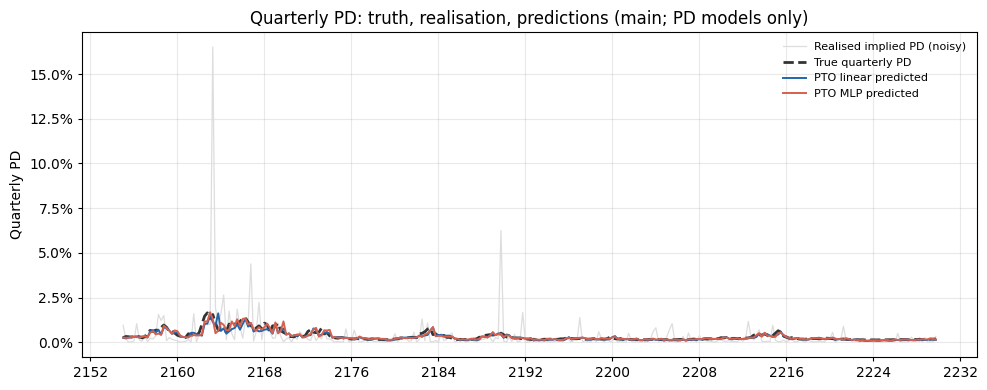

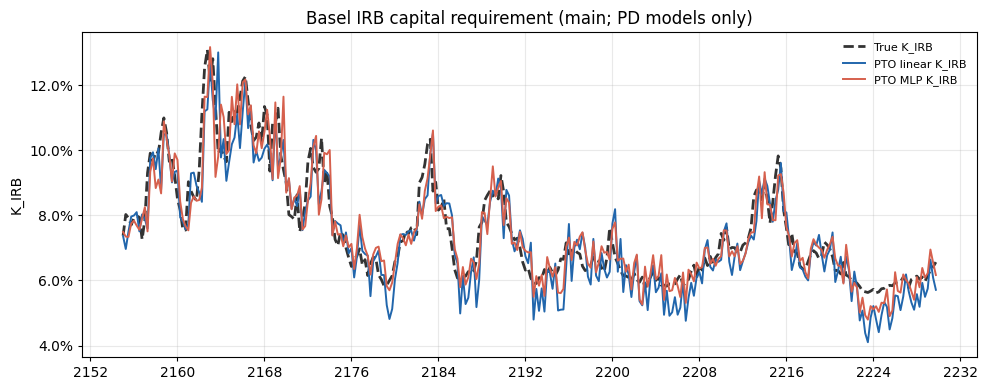

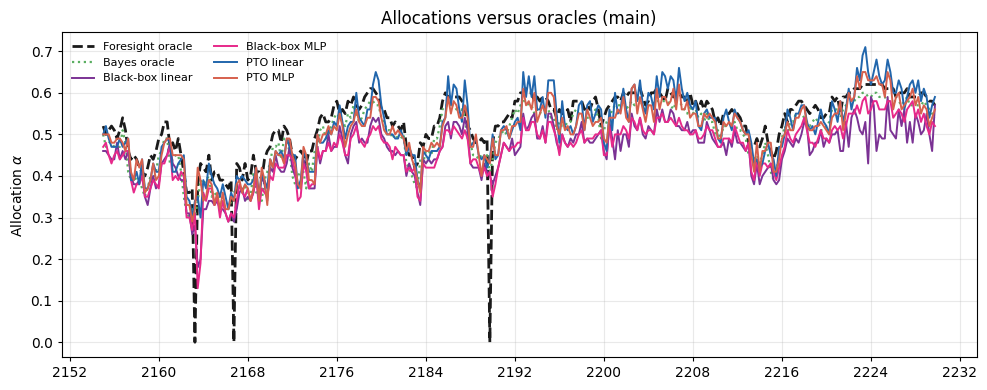

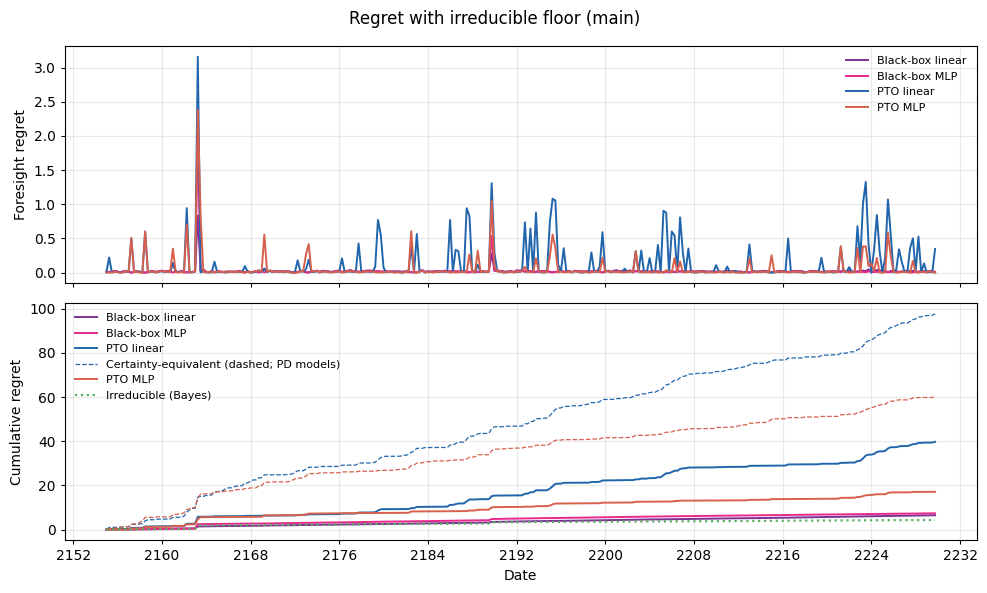

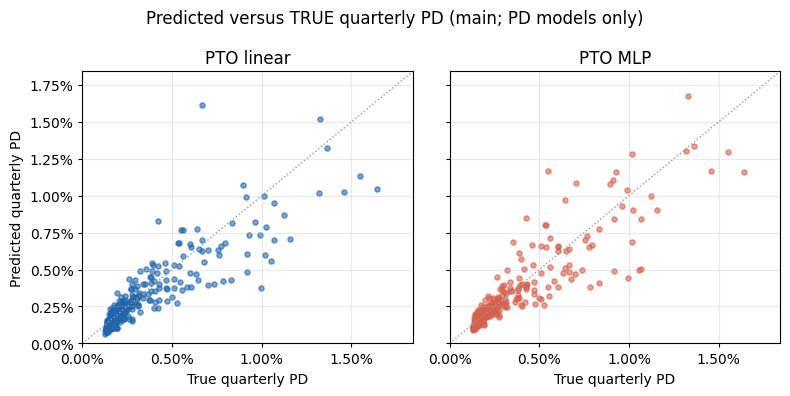

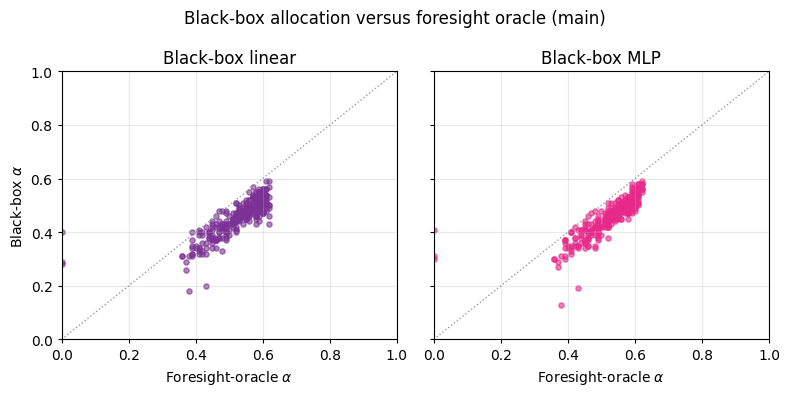

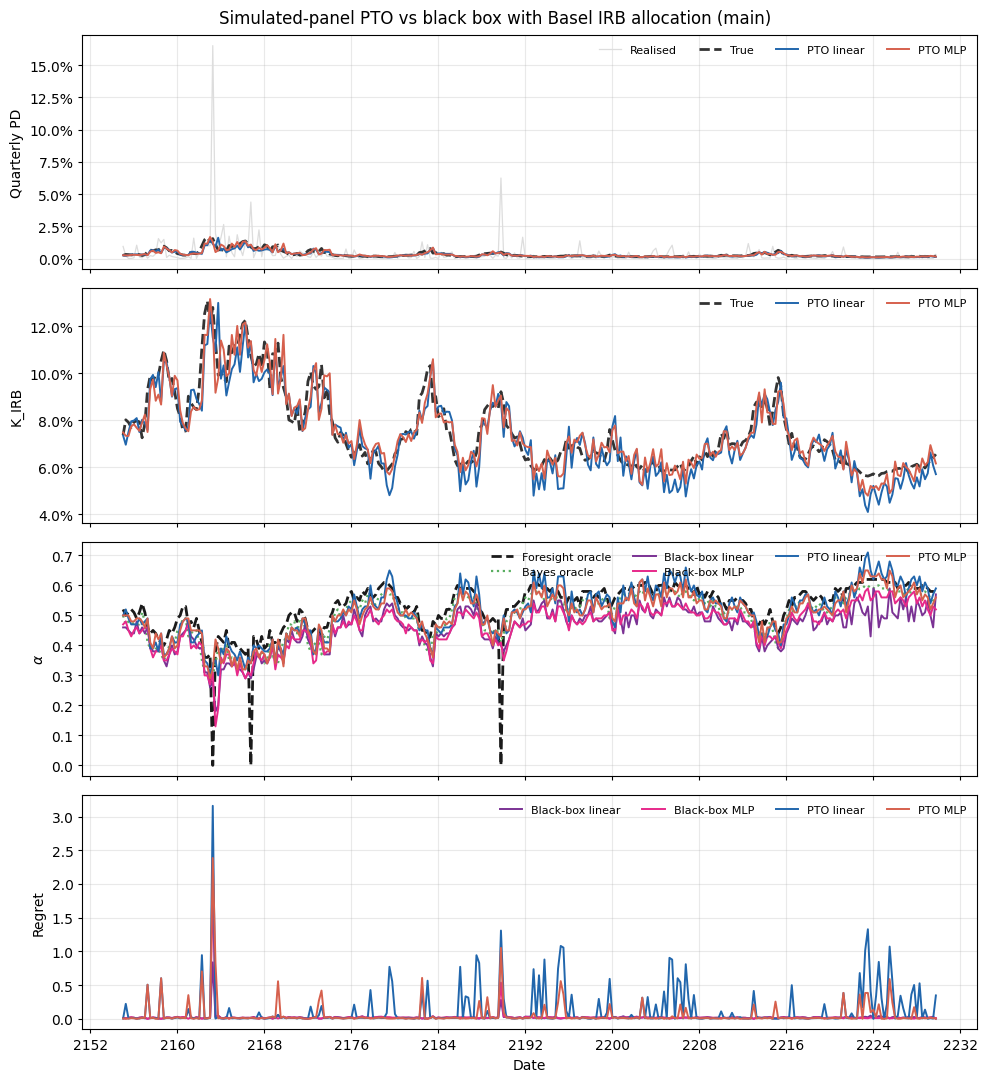

In [16]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
                     "xtick.major.size": 3, "ytick.major.size": 3, "font.sans-serif": ["DejaVu Sans"]})
MODEL_COLORS = {"linear": "#2166ac", "mlp": "#d6604d", "blackbox_linear": "#7b3294",
                "blackbox_mlp": "#e7298a", "persistence": "#bfbfbf", "persistence_ma4": "#a6761d"}
MODEL_LW = {"linear": 1.4, "mlp": 1.4, "blackbox_linear": 1.4, "blackbox_mlp": 1.4,
            "persistence": 0.8, "persistence_ma4": 1.2}
MODEL_LABELS = {"linear": "PTO linear", "mlp": "PTO MLP", "blackbox_linear": "Black-box linear",
                "blackbox_mlp": "Black-box MLP", "persistence": "Persistence (raw draw)",
                "persistence_ma4": "Persistence (4Q mean)"}
ORACLE_COLOR = "#1a1a1a"
BAYES_COLOR = "#5aae61"
TRUE_COLOR = "#333333"
REALISED_COLOR = "#dddddd"

# Which models appear in the static figures. Raw persistence is hidden by default (its
# Vasicek noise clouds every panel). PD/K_IRB panels are restricted to PD models; the
# allocation and regret panels include the black box. Any subset of MODEL_ORDER works,
# including black-box-only: the PD-based figures are skipped when no PD model is selected.
PLOT_MODELS = ["blackbox_linear", "blackbox_mlp","linear", "mlp"] #, "blackbox_linear", "blackbox_mlp", "persistence_ma4"]
PLOT_MODELS_PD = [m for m in PLOT_MODELS if m in PD_MODELS]
PLOT_MODELS_BB = [m for m in PLOT_MODELS if m in BB_MODELS]

def format_date_axis(ax, plot_df):
    years = plot_df["date"].dt.year
    step = max(2, int(np.ceil((years.max() - years.min()) / 10)))
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)


def _model_lines(ax, plot_df, col_prefix, suffix="", models=None):
    for m in (PLOT_MODELS if models is None else models):
        ax.plot(plot_df["date"], plot_df[f"{col_prefix}_{m}"], color=MODEL_COLORS[m],
                lw=MODEL_LW[m], label=f"{MODEL_LABELS[m]}{suffix}")


def plot_split(res, split_name):
    fig_dir = FIGURES_DIR / split_name
    fig_dir.mkdir(parents=True, exist_ok=True)
    plot_df = res.sort_values("date").copy()

    if PLOT_MODELS_PD:
        # 1. Quarterly PD: truth, noisy realisation, predictions (PD models only)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(plot_df["date"], plot_df["pd_q_realised"], color=REALISED_COLOR, lw=0.9, label="Realised implied PD (noisy)")
        ax.plot(plot_df["date"], plot_df["pd_q_true"], color=TRUE_COLOR, lw=2, ls="--", label="True quarterly PD")
        _model_lines(ax, plot_df, "pd_q_hat", " predicted", models=PLOT_MODELS_PD)
        ax.set_ylabel("Quarterly PD"); ax.set_title(f"Quarterly PD: truth, realisation, predictions ({split_name}; PD models only)")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8); plt.tight_layout()
        plt.savefig(fig_dir / "quarterly_pd_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

        # 2. K_IRB: true vs model-implied (PD models only)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(plot_df["date"], plot_df["k_irb_true"], color=TRUE_COLOR, lw=2, ls="--", label="True K_IRB")
        _model_lines(ax, plot_df, "k_irb_hat", " K_IRB", models=PLOT_MODELS_PD)
        ax.set_ylabel("K_IRB"); ax.set_title(f"Basel IRB capital requirement ({split_name}; PD models only)")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8); plt.tight_layout()
        plt.savefig(fig_dir / "irb_capital_requirement.png", dpi=200, bbox_inches="tight"); plt.show()
    else:
        print(f"[{split_name}] no PD models in PLOT_MODELS - skipping PD, K_IRB and PD-scatter figures.")

    # 3. Allocations: foresight oracle, Bayes oracle, all selected models
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Foresight oracle")
    ax.plot(plot_df["date"], plot_df["alpha_bayes"], color=BAYES_COLOR, lw=1.6, ls=":", label="Bayes oracle")
    _model_lines(ax, plot_df, "alpha_hat")
    ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title(f"Allocations versus oracles ({split_name})")
    format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8, ncol=2); plt.tight_layout()
    plt.savefig(fig_dir / "allocation_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

    # 4. Regret and cumulative regret, with the irreducible floor (all selected models)
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ce_labelled = False
    for m in PLOT_MODELS:
        axes[0].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        if m in PD_MODELS:
            axes[1].plot(plot_df["date"], plot_df[f"regret_ce_{m}"].cumsum(), color=MODEL_COLORS[m], lw=0.9, ls="--",
                         label="Certainty-equivalent (dashed; PD models)" if not ce_labelled else "_nolegend_")
            ce_labelled = True
    axes[1].plot(plot_df["date"], plot_df["regret_irreducible"].cumsum(), color=BAYES_COLOR, lw=1.6, ls=":",
                 label="Irreducible (Bayes)")
    axes[0].set_ylabel("Foresight regret"); axes[0].legend(frameon=False, fontsize=8)
    axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date"); axes[1].legend(frameon=False, fontsize=8)
    for ax in axes:
        format_date_axis(ax, plot_df)
    fig.suptitle(f"Regret with irreducible floor ({split_name})"); plt.tight_layout()
    plt.savefig(fig_dir / "regret.png", dpi=200, bbox_inches="tight"); plt.show()

    # 5. Predicted vs TRUE PD scatter (PD models only - skipped when none selected)
    if PLOT_MODELS_PD:
        fig, axes = plt.subplots(1, len(PLOT_MODELS_PD), figsize=(4 * len(PLOT_MODELS_PD), 4), sharex=True, sharey=True)
        lims = [0.0, max(plot_df["pd_q_true"].max(), *(plot_df[f"pd_q_hat_{m}"].max() for m in PLOT_MODELS_PD)) * 1.1]
        for ax, m in zip(np.atleast_1d(axes), PLOT_MODELS_PD):
            ax.scatter(plot_df["pd_q_true"], plot_df[f"pd_q_hat_{m}"], s=14, color=MODEL_COLORS[m], alpha=0.6)
            ax.plot(lims, lims, color="#999999", lw=1, ls=":")
            ax.set_xlim(lims); ax.set_ylim(lims)
            ax.set_title(MODEL_LABELS[m]); ax.set_xlabel("True quarterly PD")
            ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
            ax.grid(True, alpha=0.28)
        np.atleast_1d(axes)[0].set_ylabel("Predicted quarterly PD")
        fig.suptitle(f"Predicted versus TRUE quarterly PD ({split_name}; PD models only)")
        plt.tight_layout(); plt.savefig(fig_dir / "pred_vs_true_scatter.png", dpi=200, bbox_inches="tight"); plt.show()

    # 6. Black-box alpha vs oracle alpha scatter (skipped when no black-box model selected)
    if PLOT_MODELS_BB:
        fig, axes = plt.subplots(1, len(PLOT_MODELS_BB), figsize=(4 * len(PLOT_MODELS_BB), 4), sharex=True, sharey=True)
        for ax, m in zip(np.atleast_1d(axes), PLOT_MODELS_BB):
            ax.scatter(plot_df["alpha_oracle"], plot_df[f"alpha_hat_{m}"], s=14, color=MODEL_COLORS[m], alpha=0.6)
            ax.plot([0, 1], [0, 1], color="#999999", lw=1, ls=":")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.set_title(MODEL_LABELS[m]); ax.set_xlabel(r"Foresight-oracle $\alpha$")
            ax.grid(True, alpha=0.28)
        np.atleast_1d(axes)[0].set_ylabel(r"Black-box $\alpha$")
        fig.suptitle(f"Black-box allocation versus foresight oracle ({split_name})")
        plt.tight_layout(); plt.savefig(fig_dir / "bb_alpha_vs_oracle_scatter.png", dpi=200, bbox_inches="tight"); plt.show()

    # 7. Compact 4-panel thesis figure (PD rows show PD models only; empty when none selected)
    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    fig.subplots_adjust(hspace=0.08)
    axes[0].plot(plot_df["date"], plot_df["pd_q_realised"], color=REALISED_COLOR, lw=0.9, label="Realised")
    axes[0].plot(plot_df["date"], plot_df["pd_q_true"], color=TRUE_COLOR, lw=2, ls="--", label="True")
    _model_lines(axes[0], plot_df, "pd_q_hat", models=PLOT_MODELS_PD)
    axes[0].set_ylabel("Quarterly PD"); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].plot(plot_df["date"], plot_df["k_irb_true"], color=TRUE_COLOR, lw=2, ls="--", label="True")
    _model_lines(axes[1], plot_df, "k_irb_hat", models=PLOT_MODELS_PD)
    axes[1].set_ylabel("K_IRB"); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[2].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Foresight oracle")
    axes[2].plot(plot_df["date"], plot_df["alpha_bayes"], color=BAYES_COLOR, lw=1.6, ls=":", label="Bayes oracle")
    _model_lines(axes[2], plot_df, "alpha_hat")
    axes[2].set_ylabel(r"$\alpha$")
    for m in PLOT_MODELS:
        axes[3].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[3].set_ylabel("Regret"); axes[3].set_xlabel("Date")
    for ax in axes:
        format_date_axis(ax, plot_df); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=4)
    fig.suptitle(f"Simulated-panel PTO vs black box with Basel IRB allocation ({split_name})", fontsize=12)
    plt.tight_layout(); plt.savefig(fig_dir / "blackbox_sim_compact_panel.png", dpi=220, bbox_inches="tight"); plt.show()


for split_name, res in results_by_split.items():
    plot_split(res, split_name)



## Learning curves

Averaged across refits within each split; the MLP curve is the first ensemble seed only.
Averaged across refits within each split (MLP/black-box curves use the first ensemble
seed only). Early-stopped refits are padded by carrying the last value forward so the
per-epoch mean keeps constant composition. PD models: val RMSE in sim sits at the Vasicek
noise floor (~0.011), so judge convergence on the NLL panel. The black box gets its own
panel: validation REGRET, its early-stopping criterion.


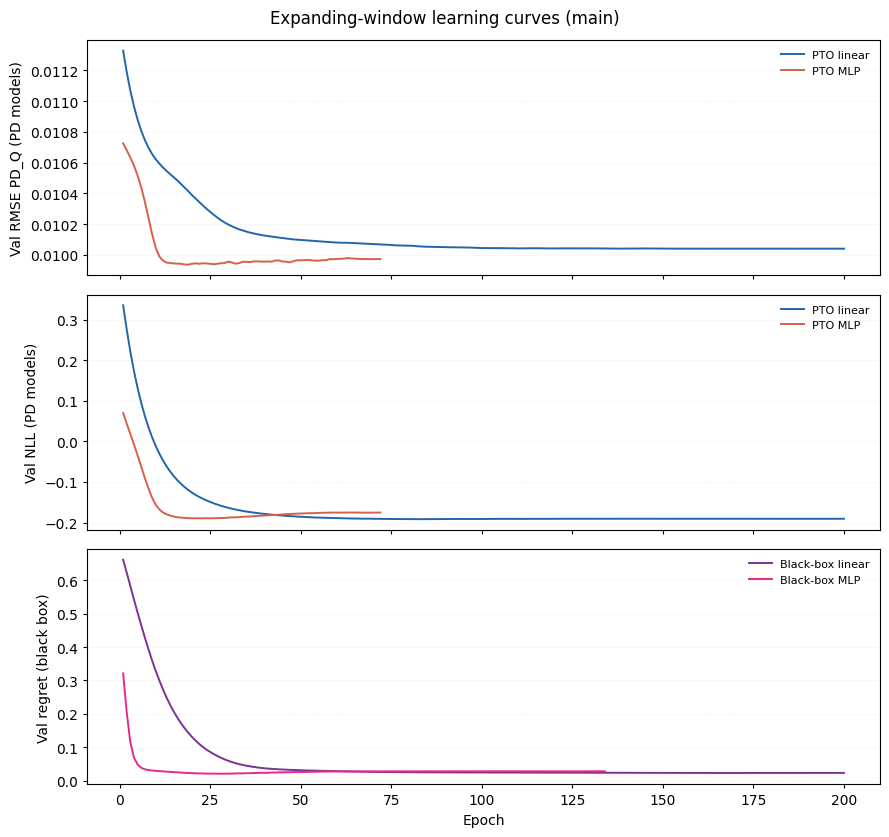

In [12]:
if not training_history.empty:
    for split_name, split_hist in training_history.groupby("split"):
        # Pad each refit's history to the model's max epoch (last value carried forward)
        # so the per-epoch mean has constant composition despite early stopping.
        padded = []
        for model_name, mg in split_hist.groupby("model"):
            max_epoch = int(mg["epoch"].max())
            for _, g in mg.groupby("test_date"):
                gg = (g.sort_values("epoch").set_index("epoch")[["val_rmse_pd_q", "val_loss"]]
                       .reindex(range(1, max_epoch + 1)).ffill().reset_index())
                gg["model"] = model_name
                padded.append(gg)
        mean_history = (pd.concat(padded, ignore_index=True)
                        .groupby(["model", "epoch"], as_index=False)
                        .agg(mean_val_rmse_pd_q=("val_rmse_pd_q", "mean"), mean_val_loss=("val_loss", "mean")))

        fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), sharex=True)
        for model_name, group in mean_history.groupby("model"):
            group = group.sort_values("epoch"); color = MODEL_COLORS.get(model_name, "grey")
            label = MODEL_LABELS.get(model_name, model_name.upper())
            if model_name in BB_MODELS:
                axes[2].plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=label)
            elif model_name in ("linear", "mlp"):
                axes[0].plot(group["epoch"], group["mean_val_rmse_pd_q"], color=color, lw=1.4, label=label)
                axes[1].plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=label)
        axes[0].set_ylabel("Val RMSE PD_Q (PD models)")
        loss_space = "NLL" if LOSS == "nll_vasicek" else f"MSE ({TARGET_TRANSFORM} space)"
        axes[1].set_ylabel(f"Val {loss_space} (PD models)")
        axes[2].set_ylabel("Val regret (black box)"); axes[2].set_xlabel("Epoch")
        for ax in axes:
            ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
        fig.suptitle(f"Expanding-window learning curves ({split_name})"); plt.tight_layout()
        fig_dir = FIGURES_DIR / split_name
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / "learning_curves.png", dpi=200, bbox_inches="tight"); plt.show()
